## Error Estimation

How to estimate error for non-Gaussian distribution

In [1]:
import sys,os
import pandas as pd
import numpy as np

from scipy import stats
import math

import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'retina'

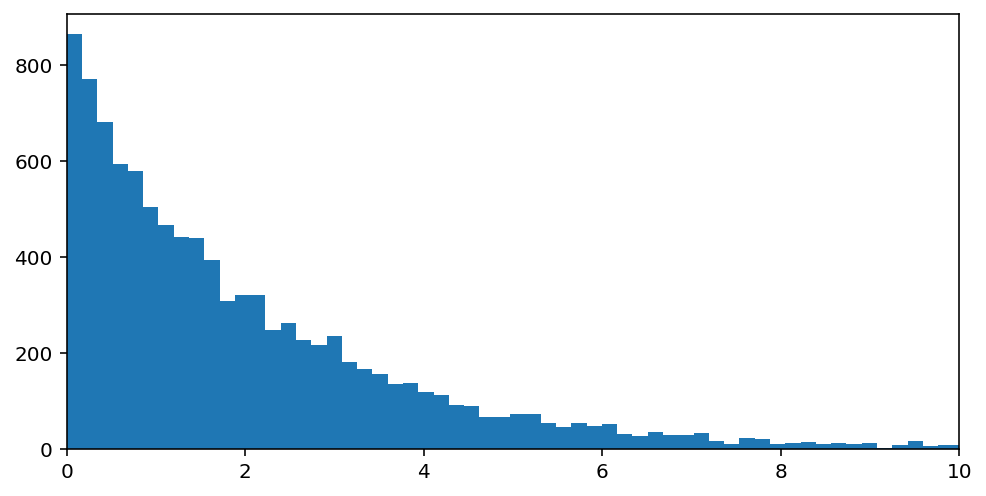

In [2]:
# Generate exponentially-distributed data
yy = np.random.exponential(scale=2.0, size=10**4)

plt.rcParams["figure.figsize"] = (8, 4) # (width, height)
fig, ax = plt.subplots(nrows=1, ncols=1)
ax.hist(yy,bins=100)
ax.set_xlim(left=0,right=10)
plt.show();

In [3]:
# Calculate mean and standard error
mean1 = yy.sum()/len(yy)
mean2 = np.mean(yy)
std1  = np.sqrt(np.square(np.subtract(yy,mean1)).mean())
std2  = np.std(yy)
print(f"mean1 = {mean1:.4f}")
print(f"mean2 = {mean2:.4f}")
print(f"std1  = {std1:.4f}")
print(f"std2  = {std2:.4f}")

mean1 = 1.9991
mean2 = 1.9991
std1  = 1.9808
std2  = 1.9808


np.sqrt(N2)*std_means = 1.9659
np.sqrt(N2)*std_means = 2.0455
np.sqrt(N2)*std_means = 2.0351
np.sqrt(N2)*std_means = 1.9320
np.sqrt(N2)*std_means = 2.0299
np.sqrt(N2)*std_means = 1.9724
np.sqrt(N2)*std_means = 1.9916
np.sqrt(N2)*std_means = 1.9836
np.sqrt(N2)*std_means = 2.0580
np.sqrt(N2)*std_means = 2.0019


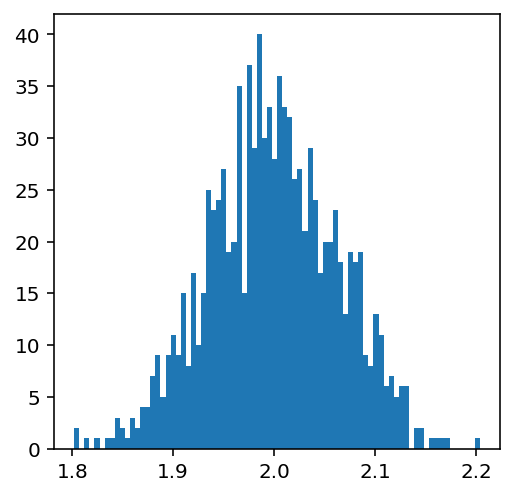

In [4]:
# Using CLT to convert to Normal distribution to estimate the error
# Split N points into N1 groups of N2 points
# Calculate mean for each group
# Estimate error of distribution of means
# Multiply by sqrt(group_size)

N1 = 1000   # N groups
N2 = 1000   # N points in each group
N  = N1*N2 # N = total number of points

for trial in range(10):
    means = []
    for ii in range(N1):
        yy = np.random.exponential(scale=2.0, size=N2)
        means.append(np.mean(yy))

    std_means = np.std(means)
    print(f"np.sqrt(N2)*std_means = {np.sqrt(N2)*std_means:.4f}")
    
plt.rcParams["figure.figsize"] = (4, 4) # (width, height)
fig, ax = plt.subplots(nrows=1, ncols=1)
ax.hist(means, bins=80)
plt.show();

np.sqrt(N2)*std_means = 1.9871
np.sqrt(N2)*std_means = 2.0577
np.sqrt(N2)*std_means = 1.9724
np.sqrt(N2)*std_means = 1.9879
np.sqrt(N2)*std_means = 2.0068
np.sqrt(N2)*std_means = 2.0609
np.sqrt(N2)*std_means = 1.8806
np.sqrt(N2)*std_means = 2.0033
np.sqrt(N2)*std_means = 1.9989
np.sqrt(N2)*std_means = 1.9757


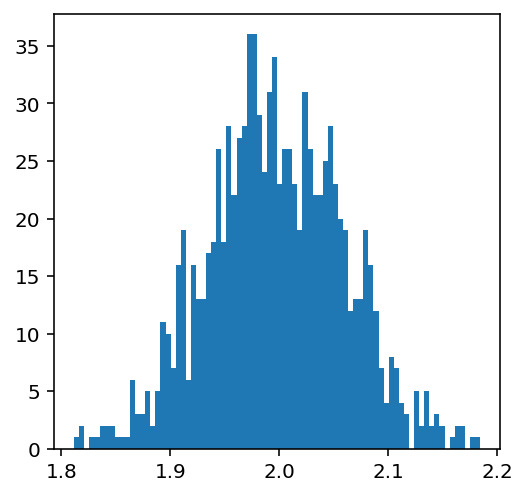

In [5]:
# Using CLT to convert to Normal distribution to estimate the error
# Bootstrap N1 groups of N2 points out of all data points
# Calculate mean for each group
# Estimate error of distribution of means
# Multiply by  sqrt(N2)
N_data = 10**6
data = np.random.exponential(scale=2.0, size=N_data)

N1 = 1000 # N groups
N2 = 1000 # N points in each group
for trial in range(10):
    means = []
    for ii in range(N1):
        yy = np.random.choice(data, replace=True, size=N1)
        means.append(np.mean(yy))

    std_means = np.std(means)
    print(f"np.sqrt(N2)*std_means = {np.sqrt(N2)*std_means:.4f}")
    
plt.rcParams["figure.figsize"] = (4, 4) # (width, height)
fig, ax = plt.subplots(nrows=1, ncols=1)
ax.hist(means, bins=80)
plt.show();

## Trying t-Test on non-Gaussian distributions (exponent)

Suppose we have two data sets A & B
with same number of points.
 
Let's try to do a t-test between them
<br>and compare it to the t-test between two distributions of mean values
<br>(which have Normal distribution because of CLT)

In [6]:
def independent_ttest(data1, data2, alpha=0.05):
    """ calculate t-test for two independent variables """
    # calculate means
    mean1, mean2 = np.mean(data1), np.mean(data2)
    # calculate standard errors
    se1, se2 = stats.sem(data1), stats.sem(data2) # ScyPy
    # standard error on the difference between the samples
    sed = np.sqrt(se1**2.0 + se2**2.0)
    # calculate the t statistic
    t_stat = (mean1 - mean2) / sed
    # degrees of freedom
    df = len(data1) + len(data2) - 2
    # calculate the critical value - a point on test distribution
    # that is compared to the test statistic 
    # to determine whether to reject the null hypothesis. 
    # You reject null hypothesis when abs(t_stat) > cv
    crit_val = stats.t.ppf(1.0 - alpha, df)
    # calculate the p-value
    p_val = (1.0 - stats.t.cdf(abs(t_stat), df)) * 2.0
    # return everything
    return t_stat, df, crit_val, p_val

# ------------------------------------------------
def print_results(t_stat, df, crit_val, p_val, alpha):
    print("-"*40)
    print(f"t_stat       = {t_stat:.4f}")
    print(f"degr.freedom = {df}")
    print(f"crit_val     = {crit_val:.4f}")
    print(f"p_val        = {p_val:.4f}")
    print("\nNull Hypothesis: two means are equal")
    print("reject if abs(t_stat) > crit_val :", end="")
    if abs(t_stat) > crit_val:
        print("  Reject")
    else:
        print("  Accept")
    print("reject if p_val      <= alpha    :", end="")
    if p_val < alpha:
        print("  Reject")
    else:
        print("  Accept")

# ------------------------------------------------
def make_data_means(mydata,N1=1000,N2=1000):
    means = []
    for ii in range(N1):
        yy = np.random.choice(mydata, replace=True, size=N2)
        means.append(np.mean(yy))
    return means

In [7]:
data1 = np.random.exponential(scale=2.0, size=10**6)
means1=make_data_means(data1,N1=1000,N2=1000)
data2 = np.random.exponential(scale=2.005, size=10**6)
means2=make_data_means(data2,N1=1000,N2=1000)

print(f"data1 : {np.mean(data1):.4f} +/- {np.std(data1):.4f}")
print(f"data2 : {np.mean(data2):.4f} +/- {np.std(data2):.4f}")
print(f"means1: {np.mean(means1):.4f} +/- {np.sqrt(N2)*np.std(means1):.4f}")
print(f"means2: {np.mean(means2):.4f} +/- {np.sqrt(N2)*np.std(means2):.4f}")

alpha = 0.05
print("\ndata1, data2")
t_stat, df, crit_val, p_val = independent_ttest(data1, data2, alpha=alpha)
print_results(t_stat, df, crit_val, p_val, alpha)
print("\nmeans1, means2")
t_stat, df, crit_val, p_val = independent_ttest(means1, means2, alpha=alpha)
print_results(t_stat, df, crit_val, p_val, alpha)

data1 : 1.9964 +/- 1.9963
data2 : 2.0039 +/- 2.0043
means1: 1.9994 +/- 1.9752
means2: 2.0054 +/- 2.0144

data1, data2
----------------------------------------
t_stat       = -2.6569
degr.freedom = 1999998
crit_val     = 1.6449
p_val        = 0.0079

Null Hypothesis: two means are equal
reject if abs(t_stat) > crit_val :  Reject
reject if p_val      <= alpha    :  Reject

means1, means2
----------------------------------------
t_stat       = -2.1472
degr.freedom = 1998
crit_val     = 1.6456
p_val        = 0.0319

Null Hypothesis: two means are equal
reject if abs(t_stat) > crit_val :  Reject
reject if p_val      <= alpha    :  Reject


In [8]:
# As you run the above code multiple times, you
# can see how p_value for means changes between runs.
# It may become very different from p_value for data
# arrays - and can negate the results of the t-test!
# Let's repeat this experiment 200 times 
# and plot histograms of p-values for both methods: data & means
# and plot graphs

In [9]:
p_vals_data = []
p_vals_means = []

for ii in range(200):
    myend = "\n" if ii % 10 == 9 else ""
    print(ii, " ", end=myend)
    data1 = np.random.exponential(scale=2.0, size=10**6)
    data2 = np.random.exponential(scale=2.005, size=10**6)
    means1=make_data_means(data1,N1=1000,N2=1000)
    means2=make_data_means(data2,N1=1000,N2=1000)
    alpha = 0.05
    t_stat, df, crit_val, p_val = independent_ttest(data1, data2, alpha=alpha)
    p_vals_data.append(p_val)
    t_stat, df, crit_val, p_val = independent_ttest(means1, means2, alpha=alpha)
    p_vals_means.append(p_val)

0  1  2  3  4  5  6  7  8  9  
10  11  12  13  14  15  16  17  18  19  
20  21  22  23  24  25  26  27  28  29  
30  31  32  33  34  35  36  37  38  39  
40  41  42  43  44  45  46  47  48  49  
50  51  52  53  54  55  56  57  58  59  
60  61  62  63  64  65  66  67  68  69  
70  71  72  73  74  75  76  77  78  79  
80  81  82  83  84  85  86  87  88  89  
90  91  92  93  94  95  96  97  98  99  
100  101  102  103  104  105  106  107  108  109  
110  111  112  113  114  115  116  117  118  119  
120  121  122  123  124  125  126  127  128  129  
130  131  132  133  134  135  136  137  138  139  
140  141  142  143  144  145  146  147  148  149  
150  151  152  153  154  155  156  157  158  159  
160  161  162  163  164  165  166  167  168  169  
170  171  172  173  174  175  176  177  178  179  
180  181  182  183  184  185  186  187  188  189  
190  191  192  193  194  195  196  197  198  199  


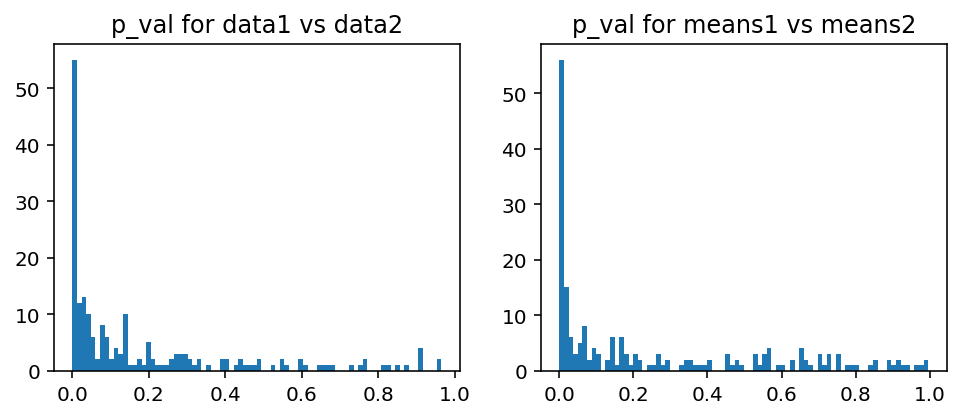

In [10]:
plt.rcParams["figure.figsize"] = (8, 3) # (width, height)
fig, axes = plt.subplots(nrows=1, ncols=2)
ax0, ax1 = axes.flatten()
_ = ax0.hist(p_vals_data,bins=80)
_ = ax0.set_title('p_val for data1 vs data2')
_ = ax1.hist(p_vals_means,bins=80)
_ = ax1.set_title('p_val for means1 vs means2')
_ = plt.show();

In [11]:
# for comparison, let's try with normal distributions
p_vals_data = []
p_vals_means = []

for ii in range(200):
    myend = "\n" if ii % 10 == 9 else ""
    print(ii, " ", end=myend)
    data1 = 2.000 + np.random.randn(10**6)
    data2 = 2.005 + np.random.randn(10**6)
    means1=make_data_means(data1,N1=1000,N2=1000)
    means2=make_data_means(data2,N1=1000,N2=1000)
    alpha = 0.05
    t_stat, df, crit_val, p_val = independent_ttest(data1, data2, alpha=alpha)
    p_vals_data.append(p_val)
    t_stat, df, crit_val, p_val = independent_ttest(means1, means2, alpha=alpha)
    p_vals_means.append(p_val)

0  1  2  3  4  5  6  7  8  9  
10  11  12  13  14  15  16  17  18  19  
20  21  22  23  24  25  26  27  28  29  
30  31  32  33  34  35  36  37  38  39  
40  41  42  43  44  45  46  47  48  49  
50  51  52  53  54  55  56  57  58  59  
60  61  62  63  64  65  66  67  68  69  
70  71  72  73  74  75  76  77  78  79  
80  81  82  83  84  85  86  87  88  89  
90  91  92  93  94  95  96  97  98  99  
100  101  102  103  104  105  106  107  108  109  
110  111  112  113  114  115  116  117  118  119  
120  121  122  123  124  125  126  127  128  129  
130  131  132  133  134  135  136  137  138  139  
140  141  142  143  144  145  146  147  148  149  
150  151  152  153  154  155  156  157  158  159  
160  161  162  163  164  165  166  167  168  169  
170  171  172  173  174  175  176  177  178  179  
180  181  182  183  184  185  186  187  188  189  
190  191  192  193  194  195  196  197  198  199  


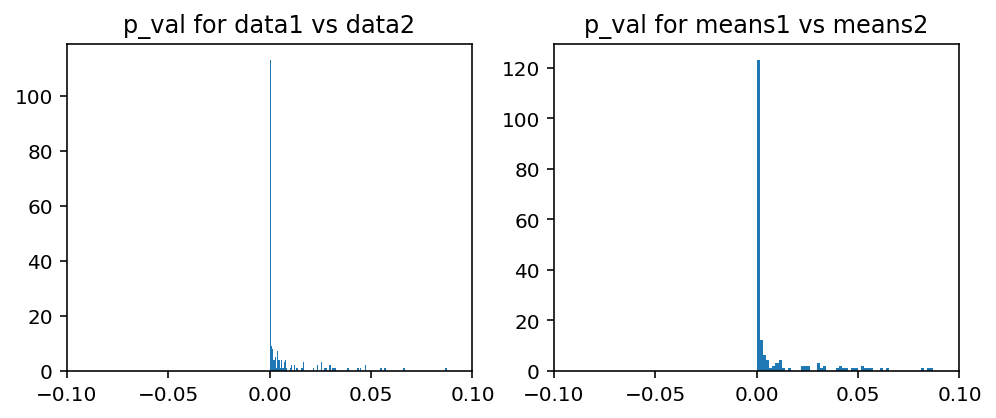

In [12]:
plt.rcParams["figure.figsize"] = (8, 3) # (width, height)
fig, axes = plt.subplots(nrows=1, ncols=2)
ax0, ax1 = axes.flatten()
_ = ax0.hist(p_vals_data,bins=400)
_ = ax0.set_xlim(left=-0.1,right=0.1)
_ = ax0.set_title('p_val for data1 vs data2')
_ = ax1.hist(p_vals_means,bins=400)
_ = ax1.set_xlim(left=-0.1,right=0.1)
_ = ax1.set_title('p_val for means1 vs means2')
_ = plt.show();

In [13]:
# Note that the above tests were run 
# with parameters close to each other: 2.0 vs 2.005
# If we make parameters father apart (for example, 2.05),
# we will see that for both cases the histograms will 
# become very narrow - tests will work in both cases.
# This may be used in practice to evaluate if
# we can trust the test. Specifically, we generate
# means, plotting histogram, and looking at its width